In [1]:
# %pip install kagglehub

In [2]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Exact filename inside the Kaggle dataset
file_path = "WA_Fn-UseC_-HR-Employee-Attrition.csv"

# Load dataset into a pandas DataFrame
df = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    "pavansubhasht/ibm-hr-analytics-attrition-dataset",
    file_path,
)

print("Rows and columns:", df.shape)
print("\nFirst 5 records:")
print(df.head())

Rows and columns: (1470, 35)

First 5 records:
   Age Attrition     BusinessTravel  DailyRate              Department  \
0   41       Yes      Travel_Rarely       1102                   Sales   
1   49        No  Travel_Frequently        279  Research & Development   
2   37       Yes      Travel_Rarely       1373  Research & Development   
3   33        No  Travel_Frequently       1392  Research & Development   
4   27        No      Travel_Rarely        591  Research & Development   

   DistanceFromHome  Education EducationField  EmployeeCount  EmployeeNumber  \
0                 1          2  Life Sciences              1               1   
1                 8          1  Life Sciences              1               2   
2                 2          2          Other              1               4   
3                 3          4  Life Sciences              1               5   
4                 2          1        Medical              1               7   

   ...  RelationshipSatisfa

In [3]:
print("Dataset general summary:", df.info())
print("\nMissing values:", df.isna().sum())
print("\nDuplicated records:", df.duplicated().sum())



<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EmployeeCount             1470 non-null   int64
 9   EmployeeNumber            1470 non-null   int64
 10  EnvironmentSatisfaction   1470 non-null   int64
 11  Gender                    1470 non-null   str  
 12  HourlyRate                1470 non-null   int64
 13  JobInvolvement            1470 non-null   int64
 14  JobLevel                  1470 non-null   int64
 15

In [4]:
df.columns = df.columns.str.strip()
df.columns = df.columns.str.lower()

In [5]:
df["attritionflag"] = df["attrition"].map({
    "Yes": 1,
    "No": 0
})

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 36 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   age                       1470 non-null   int64
 1   attrition                 1470 non-null   str  
 2   businesstravel            1470 non-null   str  
 3   dailyrate                 1470 non-null   int64
 4   department                1470 non-null   str  
 5   distancefromhome          1470 non-null   int64
 6   education                 1470 non-null   int64
 7   educationfield            1470 non-null   str  
 8   employeecount             1470 non-null   int64
 9   employeenumber            1470 non-null   int64
 10  environmentsatisfaction   1470 non-null   int64
 11  gender                    1470 non-null   str  
 12  hourlyrate                1470 non-null   int64
 13  jobinvolvement            1470 non-null   int64
 14  joblevel                  1470 non-null   int64
 15

In [7]:
df["agegroup"] = pd.cut(df["age"], bins=[0, 24, 34, 44, 54, float("inf")], labels=["Under 25", "25-34", "35-44", "45-54", "55+"], include_lowest=True)

df["incomeband"] = pd.cut(df["monthlyincome"], bins=[0, 2999, 7000, float("inf")], labels=["Low Income", "Medium Income", "High Income"])

df["distanceband"] = pd.cut(df["distancefromhome"], bins=[0, 5, 15, float("inf")], labels=["Near", "Medium Distance", "Far"]
)

df["promotionwaitband"] = pd.cut(df["yearssincelastpromotion"], bins=[-1, 0, 3, 7, float("inf")], labels=["0 Years", "1-3 Years", "4-7 Years", "8+ Years"])

df["satisfactionlevel"] = df["jobsatisfaction"].map({1: "Low", 2: "Medium", 3: "High", 4: "Very High"})

df["worklifebalancegroup"] = df["worklifebalance"].map({1: "Bad", 2: "Good", 3: "Very Good", 4: "Best"})

In [8]:
# Function to analyze attrition based on a given column and question
def analyse_attrition(column, question):
    result = (
        df.groupby(column, observed=False)["attritionflag"]
        .agg(
            employees="count",
            employees_who_left="sum",
            attrition_rate="mean"
        )
        .reset_index()
    )

    result["attrition_rate"] = (
        result["attrition_rate"] * 100
    ).round(2)

    result = result.sort_values(
        "attrition_rate",
        ascending=False
    )

    print("\n" + question)
    print(result.to_string(index=False))

    plt.figure(figsize=(9, 5))

    sns.barplot(
        data=result,
        x="attrition_rate",
        y=column,
        color="#2878B5"
    )

    plt.title(question)
    plt.xlabel("Attrition rate (%)")
    plt.ylabel("")
    plt.tight_layout()
    plt.show()

    return result

In [9]:
# Total employees, employees who left, and overall attrition rate
total_employees = len(df)
employees_who_left = df["attritionflag"].sum()
overall_rate = df["attritionflag"].mean() * 100

print("Total employees:", total_employees)
print("Employees who left:", employees_who_left)
print("Overall attrition rate:", round(overall_rate, 2), "%")

Total employees: 1470
Employees who left: 237
Overall attrition rate: 16.12 %



Which department has the highest attrition?
            department  employees  employees_who_left  attrition_rate
                 Sales        446                  92           20.63
       Human Resources         63                  12           19.05
Research & Development        961                 133           13.84


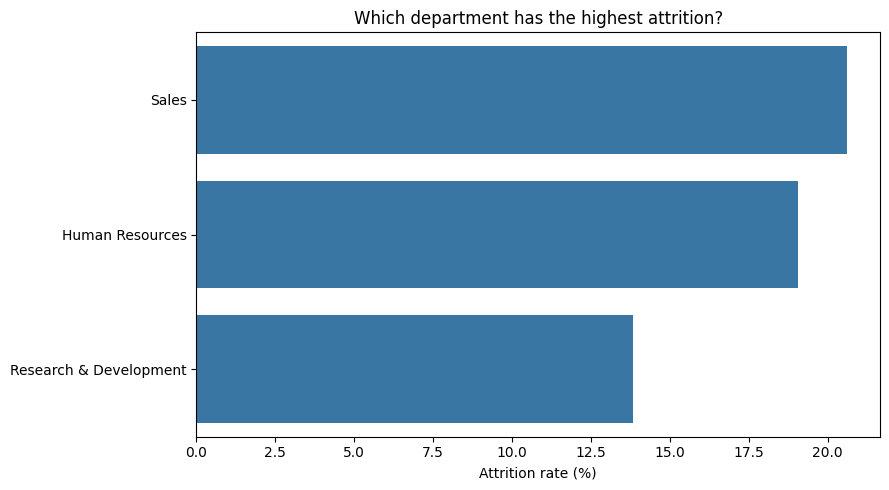


Which job roles have the highest attrition?
                  jobrole  employees  employees_who_left  attrition_rate
     Sales Representative         83                  33           39.76
    Laboratory Technician        259                  62           23.94
          Human Resources         52                  12           23.08
          Sales Executive        326                  57           17.48
       Research Scientist        292                  47           16.10
   Manufacturing Director        145                  10            6.90
Healthcare Representative        131                   9            6.87
                  Manager        102                   5            4.90
        Research Director         80                   2            2.50


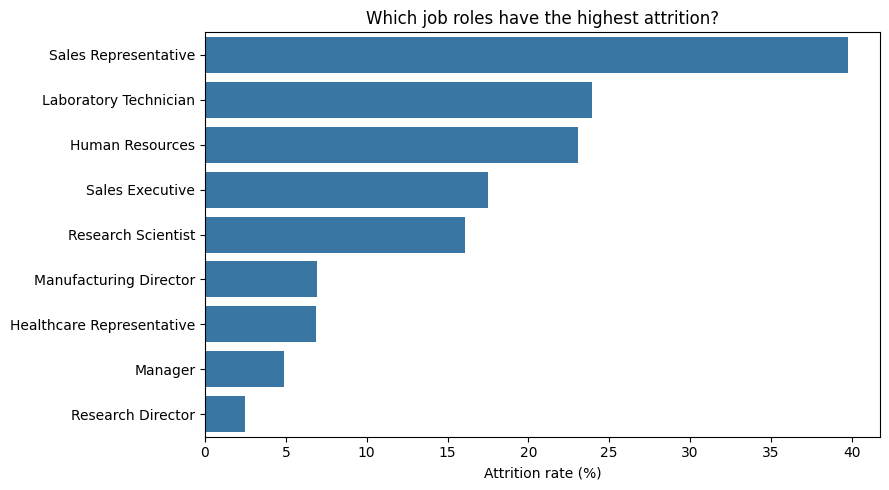


Does overtime increase attrition?
overtime  employees  employees_who_left  attrition_rate
     Yes        416                 127           30.53
      No       1054                 110           10.44


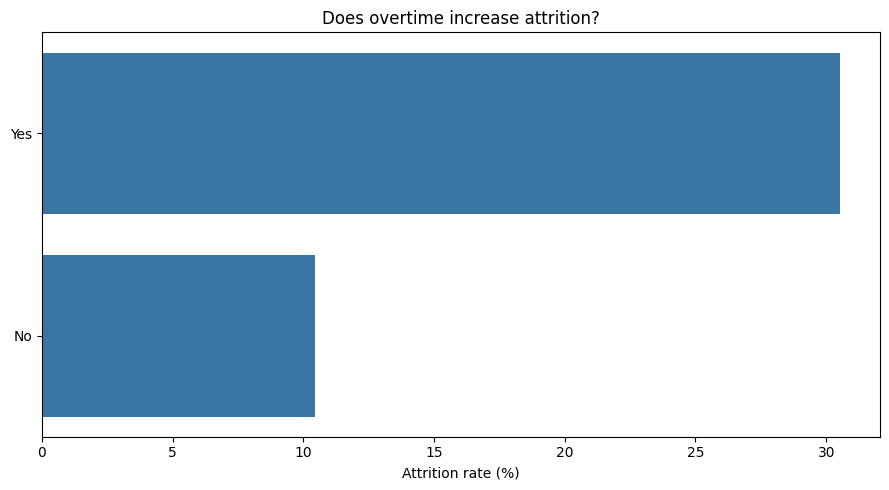


Are low-income employees more likely to leave?
   incomeband  employees  employees_who_left  attrition_rate
   Low Income        395                 113           28.61
Medium Income        640                  77           12.03
  High Income        435                  47           10.80


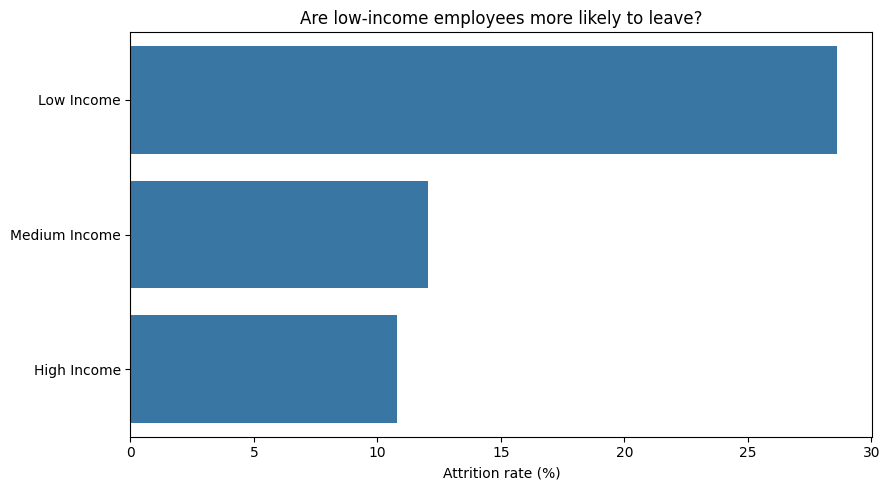


Does distance from home affect attrition?
   distanceband  employees  employees_who_left  attrition_rate
            Far        329                  68           20.67
Medium Distance        509                  82           16.11
           Near        632                  87           13.77


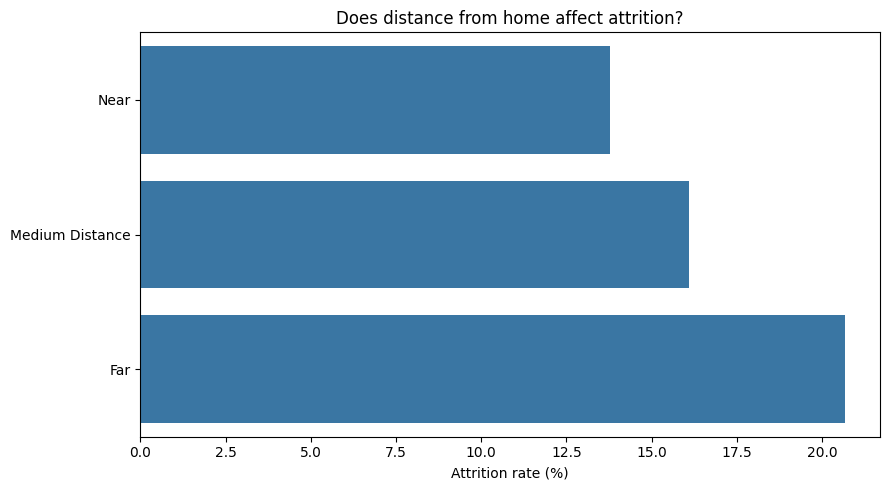


Are younger employees leaving more?
agegroup  employees  employees_who_left  attrition_rate
Under 25         97                  38           39.18
   25-34        554                 112           20.22
     55+         69                  11           15.94
   45-54        245                  25           10.20
   35-44        505                  51           10.10


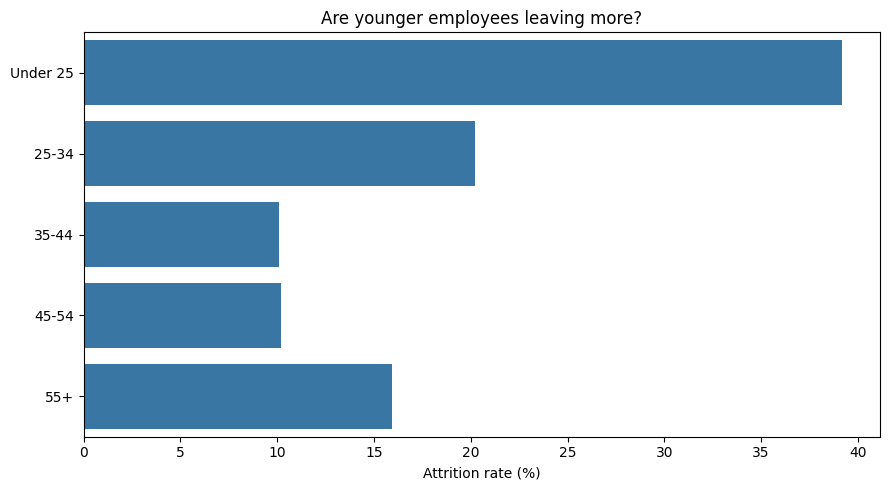


Does job satisfaction affect attrition?
satisfactionlevel  employees  employees_who_left  attrition_rate
              Low        289                  66           22.84
             High        442                  73           16.52
           Medium        280                  46           16.43
        Very High        459                  52           11.33


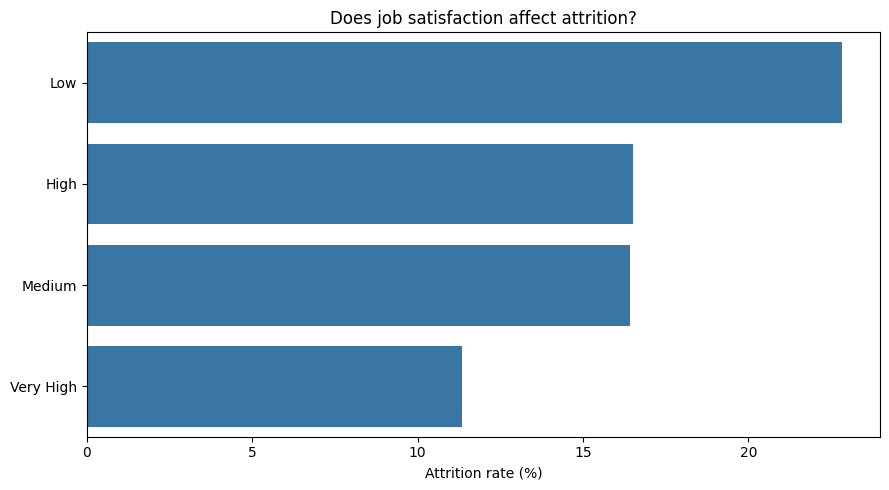


Does work-life balance affect attrition?
worklifebalancegroup  employees  employees_who_left  attrition_rate
                 Bad         80                  25           31.25
                Best        153                  27           17.65
                Good        344                  58           16.86
           Very Good        893                 127           14.22


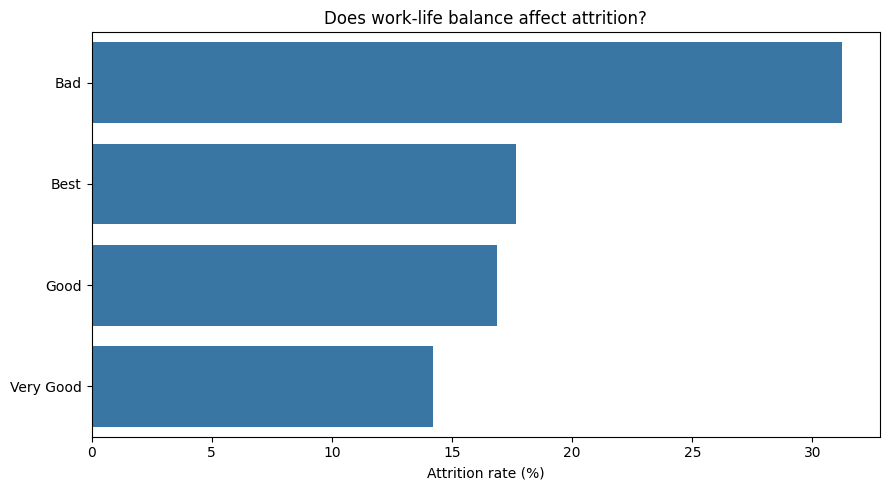


Does waiting longer for promotion increase attrition?
promotionwaitband  employees  employees_who_left  attrition_rate
          0 Years        581                 110           18.93
        1-3 Years        568                  85           14.96
        4-7 Years        214                  29           13.55
         8+ Years        107                  13           12.15


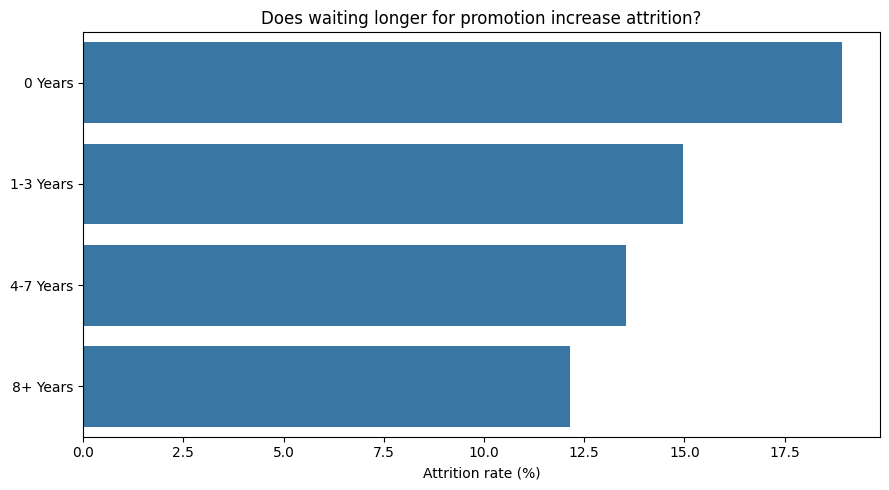

In [10]:
# Question 2: Department
department_result = analyse_attrition(
    "department",
    "Which department has the highest attrition?"
)

# Question 3: Job role
job_role_result = analyse_attrition(
    "jobrole",
    "Which job roles have the highest attrition?"
)

# Question 4: Overtime
overtime_result = analyse_attrition(
    "overtime",
    "Does overtime increase attrition?"
)

# Question 5: Income
income_result = analyse_attrition(
    "incomeband",
    "Are low-income employees more likely to leave?"
)

# Question 6: Distance
distance_result = analyse_attrition(
    "distanceband",
    "Does distance from home affect attrition?"
)

# Question 7: Age
age_result = analyse_attrition(
    "agegroup",
    "Are younger employees leaving more?"
)

# Question 8: Job satisfaction
satisfaction_result = analyse_attrition(
    "satisfactionlevel",
    "Does job satisfaction affect attrition?"
)

# Question 9: Work-life balance
work_life_result = analyse_attrition(
    "worklifebalancegroup",
    "Does work-life balance affect attrition?"
)

# Question 10: Promotion
promotion_result = analyse_attrition(
    "promotionwaitband",
    "Does waiting longer for promotion increase attrition?"
)

In [11]:
#Find High Risk Segments

segments = (
    df.groupby(
        ["department", "jobrole", "overtime", "incomeband"],
        observed=False
    )["attritionflag"]
    .agg(
        employees="count",
        employees_who_left="sum",
        attrition_rate="mean"
    )
    .reset_index()
)

segments = segments[segments["employees"] >= 10].copy()

segments["attrition_rate"] = (
    segments["attrition_rate"] * 100
).round(2)

high_risk_segments = segments.sort_values(
    ["attrition_rate", "employees_who_left"],
    ascending=False
).head(10)

print(high_risk_segments.to_string(index=False))

            department               jobrole overtime    incomeband  employees  employees_who_left  attrition_rate
                 Sales  Sales Representative      Yes    Low Income         20                  14           70.00
Research & Development Laboratory Technician      Yes    Low Income         32                  19           59.38
Research & Development    Research Scientist      Yes    Low Income         55                  27           49.09
Research & Development Laboratory Technician      Yes Medium Income         30                  12           40.00
                 Sales       Sales Executive      Yes   High Income         37                  13           35.14
                 Sales       Sales Executive      Yes Medium Income         57                  18           31.58
       Human Resources       Human Resources       No    Low Income         19                   6           31.58
                 Sales  Sales Representative       No    Low Income         48  